In [7]:
import pandas as pd
import numpy as np

np.random.seed(42)

num_days = 250

dates = pd.date_range(end=pd.Timestamp.today(), periods=num_days, freq='B')

# Generate prices
prices = [100]

for _ in range(num_days - 1):
    change = np.random.normal(0, 1)
    prices.append(prices[-1] * (1 + change / 100))

# Safety check
print(len(dates), len(prices))  # should be equal

# Build dataset safely
data = []

for date, price in zip(dates, prices):
    open_price = price * (1 + np.random.normal(0, 0.5) / 100)
    close_price = price
    volume = np.random.randint(1000, 10000)

    data.append({
        "date": date,
        "open_price": round(open_price, 2),
        "close_price": round(close_price, 2),
        "volume": volume
    })

df = pd.DataFrame(data)

print(df.head())

249 250
                        date  open_price  close_price  volume
0 2025-04-15 11:07:00.907231      100.20       100.00    8404
1 2025-04-16 11:07:00.907231      100.69       100.50    8004
2 2025-04-17 11:07:00.907231      101.19       100.36    9130
3 2025-04-18 11:07:00.907231      100.64       101.01    8253
4 2025-04-21 11:07:00.907231      101.89       102.55    3744


In [8]:
df["daily_return"] = df["close_price"].pct_change()

In [9]:
df["volatility"] = df["daily_return"].rolling(window=20).std()

In [10]:
num_simulations = 100
future_days = 30

last_price = df["close_price"].iloc[-1]

simulations = []

for _ in range(num_simulations):
    prices_sim = [last_price]
    for _ in range(future_days):
        shock = np.random.normal(0, df["daily_return"].std())
        next_price = prices_sim[-1] * (1 + shock)
        prices_sim.append(next_price)
    simulations.append(prices_sim)

In [11]:
mean_return = np.mean(df["daily_return"])
std_return = np.std(df["daily_return"])

# Value at Risk (VaR - 5%)
VaR_5 = np.percentile(df["daily_return"].dropna(), 5)

print("Mean Return:", mean_return)
print("Std Dev (Volatility):", std_return)
print("VaR (5%):", VaR_5)

Mean Return: -0.00011185055584475757
Std Dev (Volatility): 0.009602816905058511
VaR (5%): -0.015009280714158234


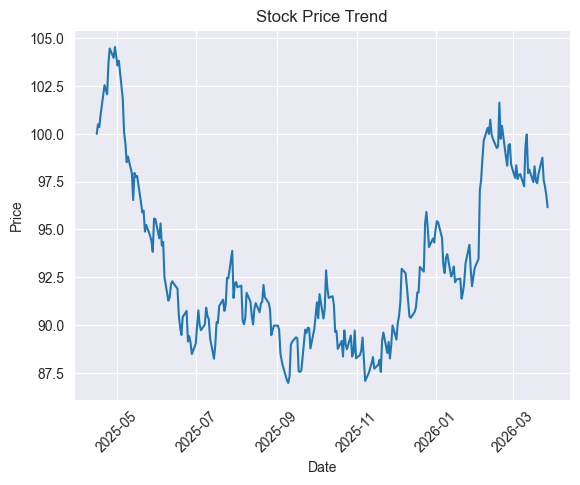

In [12]:
import matplotlib.pyplot as plt

plt.plot(df["date"], df["close_price"])

plt.title("Stock Price Trend")
plt.xlabel("Date")
plt.ylabel("Price")

plt.xticks(rotation=45)
plt.show()

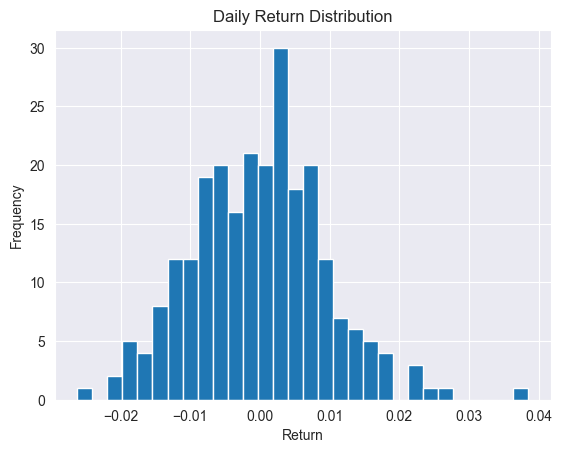

In [13]:
plt.hist(df["daily_return"].dropna(), bins=30)

plt.title("Daily Return Distribution")
plt.xlabel("Return")
plt.ylabel("Frequency")

plt.show()